In [ ]:
!git clone https://github.com/computational-cell-analytics/patho-sam.git
%cd patho-sam
#clone the repo

Cloning into 'patho-sam'...
remote: Enumerating objects: 547, done.
remote: Counting objects: 100% (229/229), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 547 (delta 136), reused 154 (delta 112), pack-reused 318 (from 1)
Receiving objects: 100% (547/547), 350.25 KiB | 12.08 MiB/s, done.
Resolving deltas: 100% (269/269), done.
/content/patho-sam


In [ ]:
#Installs repo using setup.py
!pip install -e .
!pip install staintools  # for Macenko normalisation

Obtaining file:///content/patho-sam
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for patho_sam (pyproject.toml) ... done
  Created wheel for patho_sam: filename=patho_sam-0.0.1-0.editable-py3-none-any.whl size=4055 sha256=2f7f146a2abbe64fadf8553974145a4f4d6aa135410c927298be9adc38d2d59b
  Stored in directory: /tmp/pip-ephem-wheel-cache-drjalz0u/wheels/b1/50/e4/e64e0c50dca0953d081a210d6203ffb3a5394ef436298f1c67
Successfully built patho_sam


In [ ]:
#Installs µSAM (micro-sam) from the official repository
!pip install git+https://github.com/computational-cell-analytics/micro-sam.git

  Cloning https://github.com/computational-cell-analytics/micro-sam.git to /tmp/pip-req-build-0x5ahtbs
  Running command git clone --filter=blob:none --quiet https://github.com/computational-cell-analytics/micro-sam.git /tmp/pip-req-build-0x5ahtbs
  Resolved https://github.com/computational-cell-analytics/micro-sam.git to commit 46e092b56910cdd64345e5cd3a59041ad80352b4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for micro-sam: filename=micro_sam-1.7.6-py3-none-any.whl size=258426 sha256=440740f69f93f30904c2edc3b0c314c69741d6dbf4883a29e762d7312546ed23
  Stored in directory: /tmp/pip-ephem-wheel-cache-4kcwi_j9/wheels/cd/5d/81/2059ada0d7eb4a8841bc0192adfff32dc91ec9aed6d79cc4f3
Successfully built micro-sam


In [ ]:
import torch
import numpy as np
from skimage.io import imread
import matplotlib.pyplot as plt

In [ ]:
!ls

docs		  experiments  patho_sam.egg-info  scripts
environment.yaml  LICENSE      pyproject.toml	   setup.py
examples	  patho_sam    README.md	   test


In [ ]:
cd ..


/content


In [ ]:
cd patho-sam

/content/patho-sam


In [ ]:
!ls

docs		  experiments  patho_sam.egg-info  scripts
environment.yaml  LICENSE      pyproject.toml	   setup.py
examples	  patho_sam    README.md	   test


In [ ]:
# Download Fold 1 of the PanNuke dataset, which contains histopathology image patches
!wget https://warwick.ac.uk/fac/cross_fac/tia/data/pannuke/fold_1.zip

--2026-04-17 07:10:05--  https://warwick.ac.uk/fac/cross_fac/tia/data/pannuke/fold_1.zip
Resolving warwick.ac.uk (warwick.ac.uk)... 137.205.28.41
Connecting to warwick.ac.uk (warwick.ac.uk)|137.205.28.41|:443... connected.
HTTP request sent, awaiting response... 200 
Length: 700275281 (668M) [application/zip]
Saving to: ‘fold_1.zip’

fold_1.zip          100%[===================>] 667.83M  3.83MB/s    in 1m 47s  

2026-04-17 07:11:53 (6.23 MB/s) - ‘fold_1.zip’ saved [700275281/700275281]



In [ ]:
!unzip fold_1.zip

Archive:  fold_1.zip
   creating: Fold 1/
  inflating: Fold 1/README.md        
   creating: Fold 1/masks/
  inflating: Fold 1/masks/by-nc-sa.md  
  inflating: Fold 1/masks/README.md  
   creating: Fold 1/masks/fold1/
  inflating: Fold 1/masks/fold1/masks.npy  
   creating: Fold 1/images/
   creating: Fold 1/images/fold1/
  inflating: Fold 1/images/fold1/types.npy  
  inflating: Fold 1/images/fold1/images.npy  


In [ ]:
!ls

 docs		   'Fold 1'	 patho_sam.egg-info   setup.py
 environment.yaml   fold_1.zip	 pyproject.toml       test
 examples	    LICENSE	 README.md
 experiments	    patho_sam	 scripts


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

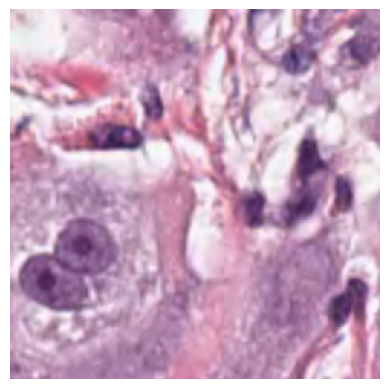

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

images = np.load("Fold 1/images/fold1/images.npy", mmap_mode="r")
masks = np.load("Fold 1/masks/fold1/masks.npy", mmap_mode="r")

image = images[0]
gt_mask = masks[0]
gt_mask_binary = (gt_mask.sum(axis=-1) > 0).astype(np.uint8)

plt.imshow(image.astype("uint8"))
plt.axis("off")

In [ ]:
!pip install segment-anything
!pip install scikit-image opencv-python matplotlib

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from skimage.measure import label

In [ ]:
#Download the pretrained SAM weights
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-04-17 07:13:51--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.14, 3.163.189.51, 3.163.189.96, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   246MB/s    in 1.5s    

2026-04-17 07:13:53 (246 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [ ]:
#Load the model
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [ ]:
#Runs automatic segmentation
#Generates the sam masks

mask_generator = SamAutomaticMaskGenerator(sam)

sam_masks = mask_generator.generate(image)
print("Number of masks:", len(masks))

Number of masks: 2656


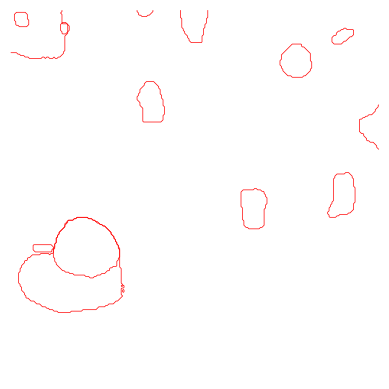

In [ ]:
'''The Segment Anything Model (SAM) consists of three major components: an image encoder, a prompt encoder,
and a mask decoder.
The image encoder is a Vision Transformer that extracts high-level image features.
The prompt encoder converts user prompts such as points, boxes, or masks into embeddings.
The mask decoder combines these embeddings with image features using a transformer
architecture to generate segmentation masks.'''

#Visualize sam masks

plt.imshow(image)
plt.axis("off")

for m in sam_masks[:20]:  # show first 20 masks
    plt.contour(m["segmentation"], colors="red", linewidths=0.5)

plt.show()

In [ ]:
#SAM returns masks individually.
#We combine them into one mask.

combined_mask = np.zeros(image.shape[:2])

for m in sam_masks:
    combined_mask[m["segmentation"]] = 1

In [ ]:
#Repo used graph clustering. (Replacing nifty.graph)

#We replace it with connected components.

instance_mask = label(combined_mask) #Gives each nucleus, a unique id


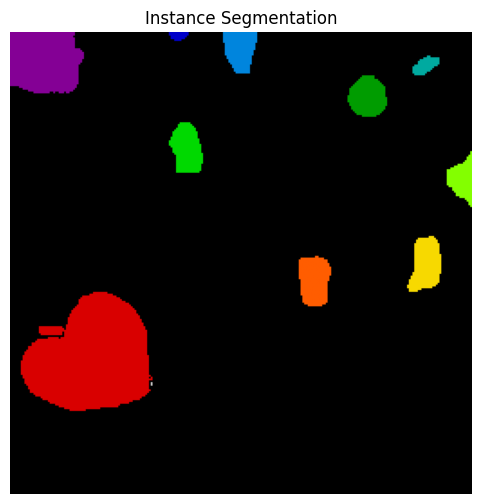

In [ ]:
#Visualize nuclei instance

plt.figure(figsize=(6,6))
plt.imshow(instance_mask, cmap="nipy_spectral")
plt.axis("off")
plt.title("Instance Segmentation")
plt.show()

In [ ]:
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage as ndi

In [ ]:
distance = ndi.distance_transform_edt(combined_mask) #Distance transform finds the center of each nucleus.


In [ ]:
#Detect nuclei centers
coords = peak_local_max(
    distance,
    footprint=np.ones((25,25)),
    labels=combined_mask.astype(int)
)

In [ ]:
#Markers tell watershed where each nucleus starts.

markers = np.zeros_like(distance, dtype=int)

for i, coord in enumerate(coords):
    markers[coord[0], coord[1]] = i + 1

In [ ]:
#This separates touching cells.

instance_mask = watershed(
    -distance,
    markers,
    mask=combined_mask
)
# Convert predicted instance segmentation to binary mask
pred_mask_binary = (instance_mask > 0).astype(np.uint8)

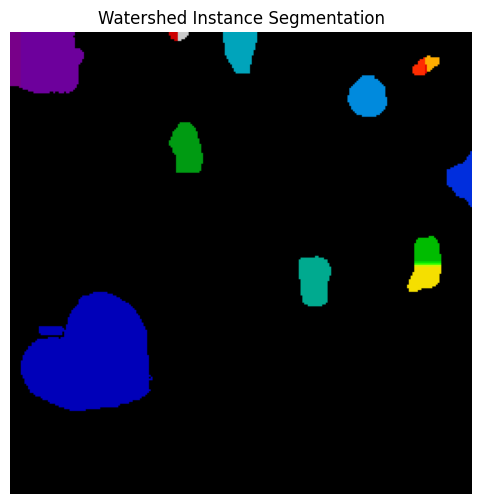

In [ ]:
#Visualize results - Shows each nucleus in different colours

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(instance_mask, cmap="nipy_spectral")
plt.axis("off")
plt.title("Watershed Instance Segmentation")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

def evaluate_segmentation(gt, pred):

    gt = gt.flatten()
    pred = pred.flatten()

    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()

    iou = intersection / union if union != 0 else 0
    dice = (2 * intersection) / (gt.sum() + pred.sum()) if (gt.sum() + pred.sum()) != 0 else 0

    precision = precision_score(gt, pred)
    recall = recall_score(gt, pred)
    f1 = f1_score(gt, pred)

    accuracy = (gt == pred).sum() / len(gt)

    return {
        "IoU": iou,
        "Dice": dice,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Pixel Accuracy": accuracy
    }

metrics = evaluate_segmentation(gt_mask_binary, pred_mask_binary)

print("Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Evaluation Metrics:
IoU: 0.1080
Dice: 0.1949
Precision: 1.0000
Recall: 0.1080
F1 Score: 0.1949
Pixel Accuracy: 0.1080


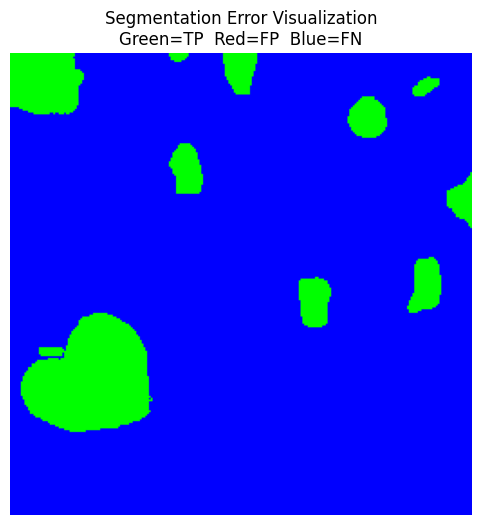

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_errors(gt, pred):

    # Initialize RGB image
    vis = np.zeros((gt.shape[0], gt.shape[1], 3))

    # True Positive (Green)
    tp = np.logical_and(gt == 1, pred == 1)
    vis[tp] = [0, 1, 0]

    # False Positive (Red)
    fp = np.logical_and(gt == 0, pred == 1)
    vis[fp] = [1, 0, 0]

    # False Negative (Blue)
    fn = np.logical_and(gt == 1, pred == 0)
    vis[fn] = [0, 0, 1]

    plt.figure(figsize=(6,6))
    plt.imshow(vis)
    plt.title("Segmentation Error Visualization\nGreen=TP  Red=FP  Blue=FN")
    plt.axis("off")
    plt.show()


visualize_errors(gt_mask_binary, pred_mask_binary)

In [ ]:
import numpy as np

# Number of images to evaluate
# We use a small number because SAM segmentation is computationally expensive
num_images = 5

# List to store Dice scores for each image
dice_scores = []

# Loop through selected images
for i in range(num_images):

    # Print progress so we know which image is currently being processed
    print(f"Processing image {i+1}/{num_images}")

    # Load the i-th histopathology image from the PanNuke dataset
    image = images[i]

    # Load the corresponding ground truth mask
    gt_mask = masks[i]

    # Convert ground truth mask to binary
    # PanNuke masks have multiple channels (5 classes of nuclei)
    # We convert it to a single mask where:
    # 1 = nucleus present
    # 0 = background
    gt_mask_binary = (gt_mask.sum(axis=-1) > 0).astype(np.uint8)

    # Run the Segment Anything Model (SAM) to generate segmentation masks
    # SAM automatically proposes multiple masks for objects in the image
    sam_masks = mask_generator.generate(image)

    # Create an empty mask with the same spatial size as the image
    combined_mask = np.zeros(image.shape[:2])

    # Combine all SAM predicted masks into a single binary mask
    # Each predicted region is marked as foreground
    for m in sam_masks:
        combined_mask[m["segmentation"]] = 1

    # Convert predicted mask to binary format
    pred_mask_binary = combined_mask.astype(np.uint8)

    # Compute intersection between ground truth and prediction
    intersection = np.logical_and(gt_mask_binary, pred_mask_binary).sum()

    # Compute Dice coefficient
    # Dice = 2 * |A ∩ B| / (|A| + |B|)
    dice = (2 * intersection) / (gt_mask_binary.sum() + pred_mask_binary.sum())

    # Store Dice score for this image
    dice_scores.append(dice)

# Print Dice score for each evaluated image
print("Dice scores:", dice_scores)

# Compute and print average Dice score across all evaluated images
print("Average Dice:", np.mean(dice_scores))

Processing image 1/5
Processing image 2/5
Processing image 3/5
Processing image 4/5
Processing image 5/5
Dice scores: [np.float64(0.19492377397986588), np.float64(0.2454721906164246), np.float64(0.2594515636411925), np.float64(0.24043173000765194), np.float64(0.1272218094530491)]
Average Dice: 0.2135002135396368


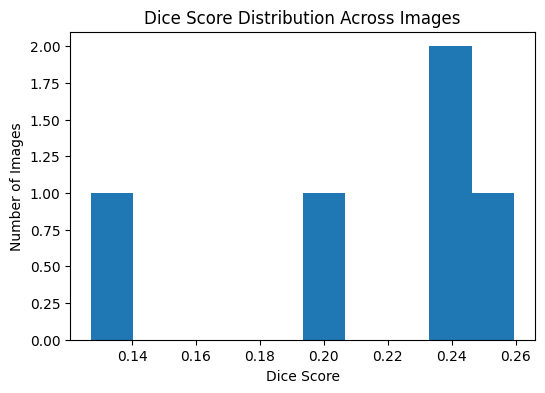

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(dice_scores, bins=10)
plt.xlabel("Dice Score")
plt.ylabel("Number of Images")
plt.title("Dice Score Distribution Across Images")
plt.show()

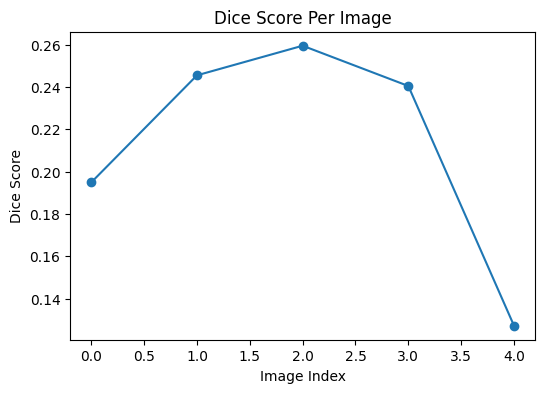

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(dice_scores, marker='o')
plt.xlabel("Image Index")
plt.ylabel("Dice Score")
plt.title("Dice Score Per Image")
plt.show()

In [ ]:
def weighted_dice(pred, gt, num_classes=5):
    total_dice = 0
    total_weight = 0

    for c in range(num_classes):
        pred_c = pred[:,:,c]
        gt_c = gt[:,:,c]

        intersection = np.sum(pred_c * gt_c)
        dice = (2 * intersection) / (np.sum(pred_c) + np.sum(gt_c) + 1e-8)

        weight = np.sum(gt_c)

        total_dice += dice * weight
        total_weight += weight

    return total_dice / (total_weight + 1e-8)

In [ ]:
num_images = 5
dice_scores = []

for i in range(num_images):

    print(f"Processing image {i+1}/{num_images}")

    image = images[i]
    gt_mask = masks[i]

    sam_masks = mask_generator.generate(image)

    pred_mask = np.zeros_like(gt_mask)

    for m in sam_masks:
        pred_mask[m["segmentation"], 0] = 1

    dice = weighted_dice(pred_mask, gt_mask)
    dice_scores.append(dice)

print("Average Dice:", np.mean(dice_scores))

Processing image 1/5
Processing image 2/5
Processing image 3/5
Processing image 4/5
Processing image 5/5
Average Dice: 0.5243843675169595


In [ ]:
import numpy as np

# -------- Dice --------
def dice_coefficient(pred, gt, eps=1e-6):
    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)

    intersection = np.sum(pred * gt)
    union = np.sum(pred) + np.sum(gt)

    return (2 * intersection + eps) / (union + eps)


# -------- IoU --------
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / (union + 1e-6)


# -------- TP / FP / FN --------
def compute_tp_fp_fn(preds, gts, threshold):
    matched_gt = set()
    TP = 0

    for p in preds:
        best_iou = 0
        best_j = -1

        for j, g in enumerate(gts):
            if j in matched_gt:
                continue

            iou = compute_iou(p, g)

            if iou > best_iou:
                best_iou = iou
                best_j = j

        if best_iou >= threshold:
            TP += 1
            matched_gt.add(best_j)

    FP = len(preds) - TP
    FN = len(gts) - TP

    return TP, FP, FN


# -------- MSA --------
def compute_msa(pred_instances, gt_instances):
    thresholds = np.arange(0.5, 1.0, 0.05)
    scores = []

    for t in thresholds:
        TP, FP, FN = compute_tp_fp_fn(pred_instances, gt_instances, t)
        score = TP / (TP + FP + FN + 1e-6)
        scores.append(score)

    return np.mean(scores)

In [ ]:
from segment_anything import SamAutomaticMaskGenerator

mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=32,              # ↑ more points → more objects
    pred_iou_thresh=0.7,
    stability_score_thresh=0.8,
    min_mask_region_area=30          # ↓ detect small nuclei
)

In [ ]:
import numpy as np
import cv2
from scipy.ndimage import label
import matplotlib.pyplot as plt


# =========================
# 🔹 IoU
# =========================
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / (union + 1e-6)


# =========================
# 🔹 TP / FP / FN
# =========================
def compute_tp_fp_fn(preds, gts, threshold):
    matched_gt = set()
    TP = 0

    for p in preds:
        best_iou = 0
        best_j = -1

        for j, g in enumerate(gts):
            if j in matched_gt:
                continue

            iou = compute_iou(p, g)

            if iou > best_iou:
                best_iou = iou
                best_j = j

        if best_iou >= threshold:
            TP += 1
            matched_gt.add(best_j)

    FP = len(preds) - TP
    FN = len(gts) - TP

    return TP, FP, FN


# =========================
# 🔹 MSA
# =========================
def compute_msa(pred_instances, gt_instances):
    thresholds = np.arange(0.5, 1.0, 0.05)
    scores = []

    for t in thresholds:
        TP, FP, FN = compute_tp_fp_fn(pred_instances, gt_instances, t)
        scores.append(TP / (TP + FP + FN + 1e-6))

    return np.mean(scores)


# =========================
# 🔹 MAIN LOOP
# =========================

num_images = 5

msa_scores = []

for i in range(num_images):

    print(f"\nProcessing image {i+1}/{num_images}")

    image = images[i]
    gt_mask = masks[i]

    # -------- Resize --------
    image = cv2.resize(image, (512, 512))
    gt_mask = cv2.resize(gt_mask, (512, 512), interpolation=cv2.INTER_NEAREST)

    # -------- SAM --------
    print("Generating SAM masks...")
    sam_masks = mask_generator.generate(image)
    print(f"Total masks: {len(sam_masks)}")

    # -------- Binary GT --------
    gt_binary = (gt_mask.sum(axis=-1) > 0).astype(np.uint8)

    # -------- Pred instances --------
    pred_instances = []
    pred_binary = np.zeros_like(gt_binary)

    # sort masks (big → small)
    sam_masks = sorted(sam_masks, key=lambda x: x["area"], reverse=True)

    for m in sam_masks:

        if m["predicted_iou"] < 0.6:
            continue

        seg = m["segmentation"]

        # remove tiny masks
        if seg.sum() < 150:
            continue

        # overlap suppression
        overlap = np.sum(pred_binary[seg]) / (seg.sum() + 1e-6)

        if overlap > 0.3:
            continue

        # accept mask
        pred_binary[seg] = 1
        pred_instances.append(seg.astype(np.uint8))

    print(f"Filtered pred instances: {len(pred_instances)}")

    # -------- GT instances --------
    gt_instances = []

    for c in range(gt_mask.shape[-1]):
        labeled_mask, num = label(gt_mask[:, :, c])

        for j in range(1, num + 1):
            instance = (labeled_mask == j).astype(np.uint8)

            if instance.sum() > 10:
                gt_instances.append(instance)

    print(f"GT instances: {len(gt_instances)}")



    # -------- MSA --------
    if len(pred_instances) == 0 or len(gt_instances) == 0:
        msa = 0
    else:
        msa = compute_msa(pred_instances, gt_instances)

    msa_scores.append(msa)

    print(f"MSA: {msa:.4f}")


# =========================
# 🔹 FINAL RESULTS
# =========================

print("\n===== FINAL RESULTS =====")
print("Average MSA:", np.mean(msa_scores))


Processing image 1/5
Generating SAM masks...
Total masks: 17
Filtered pred instances: 2
GT instances: 8
MSA: 0.0889

Processing image 2/5
Generating SAM masks...
Total masks: 34
Filtered pred instances: 4
GT instances: 10
MSA: 0.0538

Processing image 3/5
Generating SAM masks...
Total masks: 12
Filtered pred instances: 1
GT instances: 11
MSA: 0.0545

Processing image 4/5
Generating SAM masks...
Total masks: 36
Filtered pred instances: 1
GT instances: 11
MSA: 0.0545

Processing image 5/5
Generating SAM masks...
Total masks: 22
Filtered pred instances: 2
GT instances: 8
MSA: 0.1000

===== FINAL RESULTS =====
Average MSA: 0.07036518335578679


In [ ]:
# =========================
# 🔹 PROMPT-BASED SAM
# =========================

num_images = 5
msa_prompt_scores = []   # ✅ renamed

for i in range(num_images):

    print(f"\nProcessing image {i+1}/{num_images}")

    image = images[i]
    gt_mask = masks[i]

    image = cv2.resize(image, (512, 512))
    gt_mask = cv2.resize(gt_mask, (512, 512), interpolation=cv2.INTER_NEAREST)

    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8) if image.max() <= 1 else image.astype(np.uint8)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image_rgb)

    gt_binary = (gt_mask.sum(axis=-1) > 0).astype(np.uint8)

    # -------- GT instances --------
    gt_instances = []
    for c in range(gt_mask.shape[-1]):
        labeled_mask, num = label(gt_mask[:, :, c])
        for j in range(1, num + 1):
            instance = (labeled_mask == j).astype(np.uint8)
            if instance.sum() > 10:
                gt_instances.append(instance)

    print(f"GT instances: {len(gt_instances)}")

    # -------- Prompt SAM --------
    pred_instances = []

    for gt in gt_instances:
        y, x = np.where(gt)
        if len(x) == 0:
            continue

        point = np.array([[x.mean(), y.mean()]])
        label_point = np.array([1])

        masks_pred, scores, _ = predictor.predict(
            point_coords=point,
            point_labels=label_point,
            multimask_output=True
        )

        best_mask = masks_pred[np.argmax(scores)]
        pred_instances.append(best_mask.astype(np.uint8))

    print(f"Pred instances (prompt): {len(pred_instances)}")

    # -------- MSA --------
    msa = compute_msa(pred_instances, gt_instances) if len(pred_instances) > 0 else 0
    msa_prompt_scores.append(msa)

    print(f"MSA: {msa:.4f}")


print("\n===== FINAL RESULTS =====")
print("Average MSA (Prompt):", np.mean(msa_prompt_scores))


Processing image 1/5


NameError: name 'predictor' is not defined

In [ ]:
# =========================
# 🔹 ITERATIVE PROMPT-BASED SAM
# =========================

num_images = 5
msa_iterative_scores = []   # ✅ renamed

for i in range(num_images):

    print(f"\nProcessing image {i+1}/{num_images}")

    image = images[i]
    gt_mask = masks[i]

    image = cv2.resize(image, (512, 512))
    gt_mask = cv2.resize(gt_mask, (512, 512), interpolation=cv2.INTER_NEAREST)

    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8) if image.max() <= 1 else image.astype(np.uint8)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image_rgb)

    gt_binary = (gt_mask.sum(axis=-1) > 0).astype(np.uint8)

    # -------- GT instances --------
    gt_instances = []
    for c in range(gt_mask.shape[-1]):
        labeled_mask, num = label(gt_mask[:, :, c])
        for j in range(1, num + 1):
            instance = (labeled_mask == j).astype(np.uint8)
            if instance.sum() > 10:
                gt_instances.append(instance)

    print(f"GT instances: {len(gt_instances)}")

    # -------- Iterative SAM --------
    pred_instances = []

    for gt in gt_instances:

        y, x = np.where(gt)
        if len(x) == 0:
            continue

        points = [[x.mean(), y.mean()]]
        labels = [1]

        for _ in range(12):

            masks_pred, scores, _ = predictor.predict(
                point_coords=np.array(points),
                point_labels=np.array(labels),
                multimask_output=True
            )

            pred_mask = masks_pred[np.argmax(scores)]

            false_negative = np.logical_and(gt == 1, pred_mask == 0)
            false_positive = np.logical_and(gt == 0, pred_mask == 1)

            if false_negative.sum() > 0:
                y_fn, x_fn = np.where(false_negative)
                points.append([x_fn.mean(), y_fn.mean()])
                labels.append(1)

            elif false_positive.sum() > 0:
                y_fp, x_fp = np.where(false_positive)
                points.append([x_fp.mean(), y_fp.mean()])
                labels.append(0)

            else:
                break

        pred_instances.append(pred_mask.astype(np.uint8))

    print(f"Pred instances (iterative): {len(pred_instances)}")

    # -------- MSA --------
    msa = compute_msa(pred_instances, gt_instances) if len(pred_instances) > 0 else 0
    msa_iterative_scores.append(msa)

    print(f"MSA: {msa:.4f}")


print("\n===== FINAL RESULTS =====")
print("Average MSA (Iterative):", np.mean(msa_iterative_scores))

In [ ]:
# =========================
# 🔹 FINAL RESULTS + VISUALIZATION (PROMPT vs ITERATIVE)
# =========================

print("\n===== FINAL RESULTS =====")

# -------- Safe averages --------
avg_prompt = np.mean(msa_prompt_scores) if len(msa_prompt_scores) > 0 else 0
avg_iter   = np.mean(msa_iterative_scores) if len(msa_iterative_scores) > 0 else 0

print("Average MSA (Prompt):", avg_prompt)
print("Average MSA (Iterative):", avg_iter)

# -------- Check data --------
n = min(len(msa_prompt_scores), len(msa_iterative_scores))

if n == 0:
    print("⚠️ No data to plot!")
else:
    prompt_plot = msa_prompt_scores[:n]
    iter_plot   = msa_iterative_scores[:n]

    x = np.arange(n)
    width = 0.35

    plt.figure(figsize=(10, 5))

    # =========================
    # 🔹 SIDE-BY-SIDE BAR PLOT
    # =========================
    plt.bar(x - width/2, prompt_plot, width,
            label='Prompt SAM', alpha=0.8)

    plt.bar(x + width/2, iter_plot, width,
            label='Iterative SAM', alpha=0.8)

    # -------- Average lines --------
    plt.axhline(avg_prompt, linestyle='--', alpha=0.6,
                label=f'Avg Prompt={avg_prompt:.3f}')

    plt.axhline(avg_iter, linestyle='--', alpha=0.6,
                label=f'Avg Iterative={avg_iter:.3f}')

    # -------- Labels --------
    plt.xlabel("Image / Dataset")
    plt.ylabel("MSA Score")
    plt.title("MSA Comparison: Prompt vs Iterative SAM")

    plt.xticks(x, [f"Img {i+1}" for i in range(n)])
    plt.ylim(0, 1.05)

    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()